# Board2Notes — Model Karşılaştırma: v2 (Denetimli) vs v3 (Denetimli + Denetimsiz GAN)

Bu notebook iki Model-2'yi **aynı test setinde, aynı metriklerle adil** kıyaslar ve sunum materyallerini üretir:
- **Eski model (v2):** sadece denetimli eğitim
- **Yeni model (v3):** denetimli + **denetimsiz adversarial (GAN)** ince ayar

## Üretilenler
1. **Tam metrik karşılaştırma tablosu** (OCR / mask / canvas / restored) — Δ ve % iyileşme
2. **Karşılaştırma bar grafikleri**
3. **Yan yana nitel grid** (input → v2 vs v3 → hedef), özellikle ürün `white_canvas`
4. **GAN-izole analiz**: denetimli plato → GAN sonrası (denetimsizliğin tek başına katkısı)
5. **Slayt metni**: "neden denetimli+denetimsiz daha başarılı" + "denetimsiz eğitimi nasıl yaptık"

> Her iki model de aynı mimari (NAFNet-Base multi-head). Sadece ağırlık dosyaları farklı.
> Hücreleri 1 → 12 sırasıyla çalıştır.

In [1]:
# ============================================================
# 1) Ortam + Drive
# ============================================================
import os
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
import sys, json, math, time, zipfile, shutil, platform, gc
from pathlib import Path
import numpy as np, cv2
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast

print("Torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
HAS_BF16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
AMP_DTYPE = torch.bfloat16 if HAS_BF16 else torch.float16

from google.colab import drive
if not Path("/content/drive/MyDrive").exists():
    drive.mount("/content/drive", force_remount=False)
MYDRIVE = Path("/content/drive/MyDrive")
print("MYDRIVE:", MYDRIVE)

Torch: 2.11.0+cu128 | CUDA: True
Mounted at /content/drive
MYDRIVE: /content/drive/MyDrive


In [2]:
# ============================================================
# 2) CONFIG — model yolları + dataset
# ============================================================
PROJECT_DIR = MYDRIVE / "Board2Notes"
RUNS_DIR = PROJECT_DIR / "runs_nafnet_base_multihead"

# ---- ESKİ model (v2, denetimli) ----
# Eğitim notebook'un bunu şuraya kaydetti: runs.../nafnet_base64_multihead_v2_optimized/final_model.pt
# Senin gerçek production ağırlığın farklı bir yoldaysa burayı düzelt.
OLD_MODEL_CANDIDATES = [
    RUNS_DIR / "nafnet_base64_multihead_v2_optimized" / "final_model.pt",
    PROJECT_DIR / "best.pt",
    RUNS_DIR / "nafnet_base64_multihead_v2_optimized" / "stage2_full_finetune_best.pt",
]

# ---- YENİ model (v3, denetimli + GAN) ----
NEW_MODEL_CANDIDATES = [
    RUNS_DIR / "nafnet_multihead_v3_sup_gan" / "final_model.pt",
    RUNS_DIR / "nafnet_multihead_v3_sup_gan" / "final_gan_best.pt",
]

# ---- v3 eğitim raporu (GAN-izole analiz için; opsiyonel) ----
NEW_REPORT_JSON = RUNS_DIR / "nafnet_multihead_v3_sup_gan" / "report" / "metrics_report.json"

# ---- Dataset ----
DATASET_ZIP = PROJECT_DIR / "generated_multihead_dataset_v2.zip"
DATASET_LOCAL = Path("/content/generated_multihead_dataset_v2")

# ---- NAFNet mimari (her iki model de aynı) ----
NAF_WIDTH, NAF_ENC, NAF_MID, NAF_DEC = 64, [2,2,4,8], 12, [2,2,2,2]

# ---- Eval ----
VAL_BATCH = 4
MASK_THRESHOLD = 0.5

# ---- Çıktı ----
OUT_DIR = Path("/content/compare_out"); OUT_DIR.mkdir(parents=True, exist_ok=True)
DRIVE_OUT = RUNS_DIR / "comparison_v2_vs_v3"; DRIVE_OUT.mkdir(parents=True, exist_ok=True)

def first_existing(cands):
    for c in cands:
        if Path(c).exists(): return Path(c)
    return None

OLD_MODEL_PATH = first_existing(OLD_MODEL_CANDIDATES)
NEW_MODEL_PATH = first_existing(NEW_MODEL_CANDIDATES)
print("ESKİ model:", OLD_MODEL_PATH)
print("YENİ model:", NEW_MODEL_PATH)
assert NEW_MODEL_PATH is not None, "Yeni model bulunamadı. NEW_MODEL_CANDIDATES yollarını kontrol et."
if OLD_MODEL_PATH is None:
    print("\n!!! ESKİ model bulunamadı. OLD_MODEL_CANDIDATES'a gerçek v2 ağırlık dosyanın yolunu ekle.")

ESKİ model: /content/drive/MyDrive/Board2Notes/runs_nafnet_base_multihead/nafnet_base64_multihead_v2_optimized/final_model.pt
YENİ model: /content/drive/MyDrive/Board2Notes/runs_nafnet_base_multihead/nafnet_multihead_v3_sup_gan/final_model.pt


In [3]:
# ============================================================
# 3) Model mimarisi (NAFNet-Base multi-head) + esnek yükleme
# ============================================================
class LayerNorm2d(nn.Module):
    def __init__(self, c, eps=1e-6):
        super().__init__(); self.weight=nn.Parameter(torch.ones(c)); self.bias=nn.Parameter(torch.zeros(c)); self.eps=eps
    def forward(self, x):
        u=x.mean(1,keepdim=True); d=x-u; s=(d*d).mean(1,keepdim=True)
        x=d/torch.sqrt(s+self.eps); return x*self.weight[None,:,None,None]+self.bias[None,:,None,None]
class SimpleGate(nn.Module):
    def forward(self, x): a,b=x.chunk(2,1); return a*b
class NAFBlock(nn.Module):
    def __init__(self, c, dw_expand=2, ffn_expand=2):
        super().__init__(); dw=c*dw_expand
        self.conv1=nn.Conv2d(c,dw,1); self.conv2=nn.Conv2d(dw,dw,3,1,1,groups=dw); self.conv3=nn.Conv2d(dw//2,c,1)
        self.sca=nn.Sequential(nn.AdaptiveAvgPool2d(1),nn.Conv2d(dw//2,dw//2,1)); self.sg=SimpleGate()
        ffn=c*ffn_expand; self.conv4=nn.Conv2d(c,ffn,1); self.conv5=nn.Conv2d(ffn//2,c,1)
        self.norm1=LayerNorm2d(c); self.norm2=LayerNorm2d(c)
        self.beta=nn.Parameter(torch.zeros((1,c,1,1))); self.gamma=nn.Parameter(torch.zeros((1,c,1,1)))
    def forward(self, inp):
        x=self.norm1(inp); x=self.conv1(x); x=self.conv2(x); x=self.sg(x); x=x*self.sca(x); x=self.conv3(x)
        y=inp+x*self.beta; x=self.norm2(y); x=self.conv4(x); x=self.sg(x); x=self.conv5(x); return y+x*self.gamma
class NAFNetMultiHead(nn.Module):
    def __init__(self, img_channel=3, width=64, middle_blk_num=12, enc_blk_nums=(2,2,4,8), dec_blk_nums=(2,2,2,2)):
        super().__init__(); self.intro=nn.Conv2d(img_channel,width,3,1,1)
        self.encoders=nn.ModuleList(); self.decoders=nn.ModuleList(); self.ups=nn.ModuleList(); self.downs=nn.ModuleList()
        chan=width
        for n in enc_blk_nums:
            self.encoders.append(nn.Sequential(*[NAFBlock(chan) for _ in range(n)]))
            self.downs.append(nn.Conv2d(chan,2*chan,2,2)); chan*=2
        self.middle_blks=nn.Sequential(*[NAFBlock(chan) for _ in range(middle_blk_num)])
        for n in dec_blk_nums:
            self.ups.append(nn.Sequential(nn.Conv2d(chan,chan*2,1,bias=False),nn.PixelShuffle(2))); chan//=2
            self.decoders.append(nn.Sequential(*[NAFBlock(chan) for _ in range(n)]))
        self.ending_restored=nn.Conv2d(width,3,3,1,1); self.ending_ocr=nn.Conv2d(width,3,3,1,1)
        self.mask_head=nn.Sequential(nn.Conv2d(width,width//2,3,1,1),nn.GELU(),nn.Conv2d(width//2,1,3,1,1))
        self.padder_size=2**len(self.encoders)
    def check_image_size(self, x):
        _,_,h,w=x.size(); ph=(self.padder_size-h%self.padder_size)%self.padder_size; pw=(self.padder_size-w%self.padder_size)%self.padder_size
        return F.pad(x,(0,pw,0,ph))
    def forward_features(self, inp):
        _,_,H,W=inp.shape; x_in=self.check_image_size(inp); x=self.intro(x_in); skips=[]
        for enc,down in zip(self.encoders,self.downs): x=enc(x); skips.append(x); x=down(x)
        x=self.middle_blks(x)
        for dec,up,skip in zip(self.decoders,self.ups,skips[::-1]): x=up(x); x=x+skip; x=dec(x)
        return x,x_in,H,W
    def forward(self, inp):
        feat,x_in,H,W=self.forward_features(inp)
        return {"restored":(self.ending_restored(feat)+x_in)[:,:,:H,:W],
                "ocr":(self.ending_ocr(feat)+x_in)[:,:,:H,:W],
                "mask_logits":self.mask_head(feat)[:,:,:H,:W]}

def build_model():
    return NAFNetMultiHead(3, NAF_WIDTH, NAF_MID, tuple(NAF_ENC), tuple(NAF_DEC))

def safe_load(path, map_location="cpu"):
    try: return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError: return torch.load(path, map_location=map_location)
def _strip(k):
    for pre in ["module.","model.","net.","netG.","_orig_mod."]:
        if k.startswith(pre): return k[len(pre):]
    return k
def _extract(ck):
    if isinstance(ck, dict):
        for key in ["ema","params_ema","params","state_dict","model","net","weights"]:
            if key in ck and isinstance(ck[key], dict): return ck[key]
    return ck

def load_model_report(path, tag):
    """Esnek yükle + ne kadar yüklendiğini raporla (özellikle mask_head)."""
    m = build_model().to(DEVICE)
    ck = safe_load(path); sd = {_strip(k): v for k, v in _extract(ck).items()}
    msd = m.state_dict()
    loadable = {k: v for k, v in sd.items() if k in msd and tuple(msd[k].shape)==tuple(v.shape)}
    if "ending.weight" in sd and "ending_restored.weight" in msd and tuple(msd["ending_restored.weight"].shape)==tuple(sd["ending.weight"].shape):
        loadable["ending_restored.weight"]=sd["ending.weight"]; loadable["ending_restored.bias"]=sd["ending.bias"]
        loadable["ending_ocr.weight"]=sd["ending.weight"].clone(); loadable["ending_ocr.bias"]=sd["ending.bias"].clone()
    res = m.load_state_dict(loadable, strict=False)
    mask_loaded = any(k.startswith("mask_head") for k in loadable)
    print(f"[{tag}] yüklendi {len(loadable)}/{len(msd)} tensor | eksik {len(res.missing_keys)} | mask_head: {'VAR' if mask_loaded else 'YOK (!)'}")
    if not mask_loaded:
        print(f"   !!! [{tag}] mask_head yüklenmedi -> bu modelin mask/canvas metrikleri geçersiz olur.")
    m.eval()
    return m

print("Model mimarisi + yükleyici hazır.")

Model mimarisi + yükleyici hazır.


In [4]:
# ============================================================
# 4) Metrik suite + white_canvas (eğitimdeki ile birebir)
# ============================================================
def amp_ctx():
    return autocast("cuda", dtype=AMP_DTYPE, enabled=(DEVICE=="cuda"))

def _gw(ws=11, sigma=1.5, ch=3):
    c=torch.arange(ws).float()-ws//2; g=torch.exp(-(c**2)/(2*sigma**2)); g=g/g.sum()
    return (g[:,None]@g[None,:]).expand(ch,1,ws,ws).contiguous()

class SSIM(nn.Module):
    def __init__(self, ws=11, ch=3):
        super().__init__(); self.ws=ws; self.ch=ch; self.register_buffer("win",_gw(ws,1.5,ch))
    def _cs(self, x, y):
        p=self.ws//2; w=self.win.to(device=x.device, dtype=torch.float32)
        mx=F.conv2d(x,w,padding=p,groups=self.ch); my=F.conv2d(y,w,padding=p,groups=self.ch)
        mx2,my2,mxy=mx*mx,my*my,mx*my
        vx=F.conv2d(x*x,w,padding=p,groups=self.ch)-mx2; vy=F.conv2d(y*y,w,padding=p,groups=self.ch)-my2
        vxy=F.conv2d(x*y,w,padding=p,groups=self.ch)-mxy; C1,C2=0.01**2,0.03**2
        cs=(2*vxy+C2)/(vx+vy+C2+1e-8); ss=((2*mxy+C1)/(mx2+my2+C1+1e-8))*cs; return ss.mean(),cs.mean()
    def ssim_value(self, x, y): return self._cs(x.float().clamp(0,1), y.float().clamp(0,1))[0]
    def ms_ssim_value(self, x, y, scales=3):
        x=x.float().clamp(0,1); y=y.float().clamp(0,1); vals=[]
        for i in range(scales):
            v,cs=self._cs(x,y)
            if i<scales-1: vals.append(cs.clamp(min=1e-6)); x=F.avg_pool2d(x,2); y=F.avg_pool2d(y,2)
            else: vals.append(v.clamp(min=1e-6))
        w=torch.tensor([0.3,0.3,0.4],device=x.device)[:scales]; w=w/w.sum(); out=torch.tensor(1.0,device=x.device)
        for vv,wi in zip(vals,w): out=out*(vv**wi)
        return out

class EdgeLoss(nn.Module):
    def __init__(self):
        super().__init__(); kx=torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]],dtype=torch.float32)
        self.register_buffer("kx",kx.view(1,1,3,3)); self.register_buffer("ky",kx.t().contiguous().view(1,1,3,3))
    def grad(self, x):
        x=x.float().clamp(0,1); g=0.299*x[:,0:1]+0.587*x[:,1:2]+0.114*x[:,2:3]
        gx=F.conv2d(g,self.kx.to(x.device),padding=1); gy=F.conv2d(g,self.ky.to(x.device),padding=1)
        return torch.sqrt(gx*gx+gy*gy+1e-6)
    def forward(self, x, y): return F.l1_loss(self.grad(x), self.grad(y))

_ssim = SSIM().to(DEVICE); _edge = EdgeLoss().to(DEVICE)

def psnr_t(pred, target):
    pred=pred.float().clamp(0,1); target=target.float().clamp(0,1)
    return (-10*torch.log10(F.mse_loss(pred,target)+1e-10)).item()

def _to_gray_np(t):
    a=t.float().clamp(0,1).cpu().numpy(); return (0.299*a[0]+0.587*a[1]+0.114*a[2]).astype(np.float32)

def boundary_f1_np(pb, gb, tol=2):
    def bd(m): m=m.astype(np.uint8); return m-cv2.erode(m,np.ones((3,3),np.uint8),1)
    bp=bd(pb); bg=bd(gb); k=2*tol+1
    bgd=cv2.dilate(bg,np.ones((k,k),np.uint8)); bpd=cv2.dilate(bp,np.ones((k,k),np.uint8))
    pr=(bp*bgd).sum()/(bp.sum()+1e-6); rc=(bg*bpd).sum()/(bg.sum()+1e-6); return float(2*pr*rc/(pr+rc+1e-6))

def make_white_canvas_np(ocr_rgb, mask_prob, soften=True):
    a=mask_prob.copy()
    if soften: a=cv2.GaussianBlur(a,(3,3),0)
    a=np.clip(a,0,1)[...,None]; ocr=np.transpose(ocr_rgb,(1,2,0)); white=np.ones_like(ocr)
    return np.clip(white*(1-a)+ocr*a,0,1)

def batch_to_device(b):
    return {k:(v.cuda(non_blocking=True) if torch.is_tensor(v) else v) for k,v in b.items()}

@torch.no_grad()
def evaluate_full(model_eval, loader, desc="eval"):
    model_eval.eval()
    acc = {k:0.0 for k in ["rest_psnr","rest_ssim","rest_mae",
        "ocr_psnr","ocr_ssim","ocr_msssim","ocr_mae","ocr_edge_f1","ocr_text_contrast","ocr_sharpness",
        "mask_iou","mask_dice","mask_prec","mask_rec","mask_f1","mask_bf1","mask_acc",
        "canvas_psnr","canvas_ssim"]}
    n=0
    for b in tqdm(loader, desc=desc, leave=False):
        b=batch_to_device(b); bs=b["input"].size(0)
        with amp_ctx():
            o=model_eval(b["input"]); rest=o["restored"].clamp(0,1); ocr=o["ocr"].clamp(0,1); mlog=o["mask_logits"].float()
        acc["rest_psnr"]+=psnr_t(rest,b["target_restored"])*bs
        acc["rest_ssim"]+=_ssim.ssim_value(rest,b["target_restored"]).item()*bs
        acc["rest_mae"]+=F.l1_loss(rest.float(),b["target_restored"].float()).item()*bs
        acc["ocr_psnr"]+=psnr_t(ocr,b["target_ocr"])*bs
        acc["ocr_ssim"]+=_ssim.ssim_value(ocr,b["target_ocr"]).item()*bs
        acc["ocr_msssim"]+=_ssim.ms_ssim_value(ocr,b["target_ocr"]).item()*bs
        acc["ocr_mae"]+=F.l1_loss(ocr.float(),b["target_ocr"].float()).item()*bs
        acc["ocr_edge_f1"]+=(1.0-_edge(ocr,b["target_ocr"]).item())*bs
        pm=(torch.sigmoid(mlog)>MASK_THRESHOLD).float(); gt=(b["text_mask"].float()>0.5).float(); d=(1,2,3)
        tp=(pm*gt).sum(d); fp=(pm*(1-gt)).sum(d); fn=((1-pm)*gt).sum(d); tn=((1-pm)*(1-gt)).sum(d)
        iou=(tp+1e-6)/(tp+fp+fn+1e-6); dice=(2*tp+1e-6)/(2*tp+fp+fn+1e-6)
        prec=(tp+1e-6)/(tp+fp+1e-6); rec=(tp+1e-6)/(tp+fn+1e-6); f1=2*prec*rec/(prec+rec+1e-6)
        accu=(tp+tn+1e-6)/(tp+tn+fp+fn+1e-6)
        acc["mask_iou"]+=iou.mean().item()*bs; acc["mask_dice"]+=dice.mean().item()*bs
        acc["mask_prec"]+=prec.mean().item()*bs; acc["mask_rec"]+=rec.mean().item()*bs
        acc["mask_f1"]+=f1.mean().item()*bs; acc["mask_acc"]+=accu.mean().item()*bs
        probm=torch.sigmoid(mlog)
        for i in range(bs):
            og=_to_gray_np(ocr[i]); mk_gt=gt[i,0].cpu().numpy(); mk_pr=pm[i,0].cpu().numpy()
            tx=og[mk_gt>0.5]; bgp=og[mk_gt<=0.5]
            acc["ocr_text_contrast"]+=(float(bgp.mean()-tx.mean()) if tx.size>0 and bgp.size>0 else 0.0)
            acc["ocr_sharpness"]+=float(cv2.Laplacian(og,cv2.CV_32F).var())
            acc["mask_bf1"]+=boundary_f1_np(mk_pr.astype(np.uint8),mk_gt.astype(np.uint8))
            pc=make_white_canvas_np(ocr[i].cpu().numpy(),probm[i,0].cpu().numpy())
            gc_=make_white_canvas_np(b["target_ocr"][i].cpu().numpy(),mk_gt)
            acc["canvas_psnr"]+=psnr_t(torch.from_numpy(pc).permute(2,0,1)[None],torch.from_numpy(gc_).permute(2,0,1)[None])
            acc["canvas_ssim"]+=_ssim.ssim_value(torch.from_numpy(pc).permute(2,0,1)[None].to(DEVICE),
                                                 torch.from_numpy(gc_).permute(2,0,1)[None].to(DEVICE)).item()
        n+=bs
    n=max(1,n)
    return {k:v/n for k,v in acc.items()}

print("Metrik suite hazır.")

Metrik suite hazır.


In [5]:
# ============================================================
# 5) Test seti yükle (aynı dataset, test split)
# ============================================================
def find_dataset_root(base):
    base=Path(base); cands=[base, base/"generated_multihead_dataset_v2"]+[p for p in base.glob("*") if p.is_dir()]
    for c in cands:
        if all((c/sp/sub).exists() for sp in ["train","val","test"] for sub in ["input","target_restored","target_ocr","text_mask"]):
            return c
    return None

root=find_dataset_root("/content")
if root is None:
    assert DATASET_ZIP.exists(), f"Dataset ZIP yok: {DATASET_ZIP}"
    print("ZIP açılıyor...")
    with zipfile.ZipFile(DATASET_ZIP) as z: z.extractall("/content")
    root=find_dataset_root("/content")
assert root is not None, "Dataset root bulunamadı."
DATASET_LOCAL=root; print("Dataset:", DATASET_LOCAL)

def read_rgb(p):
    img=cv2.imread(str(p),cv2.IMREAD_COLOR); return cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
def read_gray(p): return cv2.imread(str(p),cv2.IMREAD_GRAYSCALE)
def to_t_rgb(a): return torch.from_numpy(np.ascontiguousarray(a)).permute(2,0,1).float()/255.0
def to_t_mask(a): return torch.from_numpy(np.ascontiguousarray(a)).unsqueeze(0).float()/255.0

class TestDS(Dataset):
    def __init__(self, root, split="test", cache=True):
        self.root=Path(root); self.split=split
        self.ind=self.root/split/"input"; self.rd=self.root/split/"target_restored"
        self.od=self.root/split/"target_ocr"; self.md_=self.root/split/"text_mask"
        self.files=sorted(p.name for p in self.ind.glob("*.png")); assert self.files
        self.mem=[]
        for f in tqdm(self.files, desc=f"cache {split}"):
            self.mem.append((read_rgb(self.ind/f),read_rgb(self.rd/f),read_rgb(self.od/f),read_gray(self.md_/f)))
    def __len__(self): return len(self.files)
    def __getitem__(self, i):
        inp,rest,ocr,mask=self.mem[i]
        return {"input":to_t_rgb(inp),"target_restored":to_t_rgb(rest),"target_ocr":to_t_rgb(ocr),
                "text_mask":to_t_mask(mask),"file":self.files[i]}

test_ds=TestDS(DATASET_LOCAL,"test")
test_loader=DataLoader(test_ds,batch_size=VAL_BATCH,shuffle=False,num_workers=2,pin_memory=True)
print("Test örnek:", len(test_ds), "| batch:", VAL_BATCH)

ZIP açılıyor...
Dataset: /content/generated_multihead_dataset_v2


cache test:   0%|          | 0/156 [00:00<?, ?it/s]

Test örnek: 156 | batch: 4


In [6]:
# ============================================================
# 6) Her iki modeli yükle
# ============================================================
assert OLD_MODEL_PATH is not None, "ESKİ model yolu yok. Cell 2'de OLD_MODEL_CANDIDATES'ı düzelt."
print("ESKİ (v2, denetimli):", OLD_MODEL_PATH)
old_model = load_model_report(OLD_MODEL_PATH, "v2-denetimli")
print("\nYENİ (v3, denetimli+GAN):", NEW_MODEL_PATH)
new_model = load_model_report(NEW_MODEL_PATH, "v3-sup+GAN")

ESKİ (v2, denetimli): /content/drive/MyDrive/Board2Notes/runs_nafnet_base_multihead/nafnet_base64_multihead_v2_optimized/final_model.pt
[v2-denetimli] yüklendi 670/670 tensor | eksik 0 | mask_head: VAR

YENİ (v3, denetimli+GAN): /content/drive/MyDrive/Board2Notes/runs_nafnet_base_multihead/nafnet_multihead_v3_sup_gan/final_model.pt
[v3-sup+GAN] yüklendi 670/670 tensor | eksik 0 | mask_head: VAR


In [7]:
# ============================================================
# 7) Her iki modeli aynı test setinde değerlendir
# ============================================================
print("ESKİ model değerlendiriliyor...")
old_metrics = evaluate_full(old_model, test_loader, desc="v2 eval")
print("YENİ model değerlendiriliyor...")
new_metrics = evaluate_full(new_model, test_loader, desc="v3 eval")

print("\n--- ESKİ (v2) ---")
print(json.dumps({k:round(v,4) for k,v in old_metrics.items()}, indent=2, ensure_ascii=False))
print("\n--- YENİ (v3) ---")
print(json.dumps({k:round(v,4) for k,v in new_metrics.items()}, indent=2, ensure_ascii=False))

ESKİ model değerlendiriliyor...


v2 eval:   0%|          | 0/39 [00:00<?, ?it/s]

YENİ model değerlendiriliyor...


v3 eval:   0%|          | 0/39 [00:00<?, ?it/s]


--- ESKİ (v2) ---
{
  "rest_psnr": 18.0867,
  "rest_ssim": 0.1449,
  "rest_mae": 0.0659,
  "ocr_psnr": 17.9198,
  "ocr_ssim": 0.1537,
  "ocr_msssim": 0.4457,
  "ocr_mae": 0.0684,
  "ocr_edge_f1": 0.9612,
  "ocr_text_contrast": 0.4009,
  "ocr_sharpness": 0.1046,
  "mask_iou": 0.5827,
  "mask_dice": 0.7196,
  "mask_prec": 0.6144,
  "mask_rec": 0.8769,
  "mask_f1": 0.7195,
  "mask_bf1": 0.9709,
  "mask_acc": 0.9916,
  "canvas_psnr": 30.7433,
  "canvas_ssim": 0.9767
}

--- YENİ (v3) ---
{
  "rest_psnr": 20.9711,
  "rest_ssim": 0.2305,
  "rest_mae": 0.0569,
  "ocr_psnr": 24.8143,
  "ocr_ssim": 0.5082,
  "ocr_msssim": 0.7888,
  "ocr_mae": 0.0471,
  "ocr_edge_f1": 0.9597,
  "ocr_text_contrast": 0.3887,
  "ocr_sharpness": 0.0148,
  "mask_iou": 0.5778,
  "mask_dice": 0.7159,
  "mask_prec": 0.6077,
  "mask_rec": 0.8808,
  "mask_f1": 0.7159,
  "mask_bf1": 0.9712,
  "mask_acc": 0.9914,
  "canvas_psnr": 30.8369,
  "canvas_ssim": 0.9767
}


In [8]:
# ============================================================
# 8) Karşılaştırma tablosu (Δ + % iyileşme) + Markdown kaydet
# ============================================================
NICE = {"ocr_psnr":"OCR PSNR (dB) ↑","ocr_ssim":"OCR SSIM ↑","ocr_msssim":"OCR MS-SSIM ↑",
        "ocr_edge_f1":"OCR Edge-F1 ↑","ocr_text_contrast":"OCR Text Contrast ↑","ocr_mae":"OCR MAE ↓",
        "mask_iou":"Mask IoU ↑","mask_dice":"Mask Dice ↑","mask_f1":"Mask F1 ↑","mask_bf1":"Mask Boundary-F1 ↑",
        "mask_prec":"Mask Precision ↑","mask_rec":"Mask Recall ↑","mask_acc":"Mask Accuracy ↑",
        "canvas_psnr":"Canvas PSNR (dB) ↑","canvas_ssim":"Canvas SSIM ↑",
        "rest_psnr":"Restored PSNR (dB) ↑","rest_ssim":"Restored SSIM ↑"}
ORDER = ["ocr_psnr","ocr_ssim","ocr_msssim","ocr_edge_f1","ocr_text_contrast",
         "mask_dice","mask_f1","mask_iou","mask_bf1","mask_prec","mask_rec","mask_acc",
         "canvas_psnr","canvas_ssim","rest_psnr","rest_ssim"]
def pct(o,n): return float("nan") if abs(o)<1e-9 else (n-o)/abs(o)*100

print(f"{'Metrik':<26}{'Eski v2':>10}{'Yeni v3':>10}{'Δ':>10}{'%':>9}")
print("-"*65)
md=["# Board2Notes — v2 (denetimli) vs v3 (denetimli+GAN) — Test Seti Karşılaştırması\n",
    "| Metrik | Eski (v2, denetimli) | Yeni (denetimli+GAN) | Δ | % İyileşme |","|---|---|---|---|---|"]
for k in ORDER:
    o=old_metrics[k]; n=new_metrics[k]; d=n-o; p=pct(o,n)
    print(f"{NICE[k]:<26}{o:>10.4f}{n:>10.4f}{d:>+10.4f}{p:>+8.1f}%")
    md.append(f"| {NICE[k]} | {o:.4f} | {n:.4f} | {d:+.4f} | {p:+.1f}% |")
(OUT_DIR/"comparison_table.md").write_text("\n".join(md), encoding="utf-8")
print("\nKaydedildi: comparison_table.md")

Metrik                       Eski v2   Yeni v3         Δ        %
-----------------------------------------------------------------
OCR PSNR (dB) ↑              17.9198   24.8143   +6.8946   +38.5%
OCR SSIM ↑                    0.1537    0.5082   +0.3545  +230.7%
OCR MS-SSIM ↑                 0.4457    0.7888   +0.3432   +77.0%
OCR Edge-F1 ↑                 0.9612    0.9597   -0.0014    -0.2%
OCR Text Contrast ↑           0.4009    0.3887   -0.0122    -3.0%
Mask Dice ↑                   0.7196    0.7159   -0.0037    -0.5%
Mask F1 ↑                     0.7195    0.7159   -0.0037    -0.5%
Mask IoU ↑                    0.5827    0.5778   -0.0049    -0.8%
Mask Boundary-F1 ↑            0.9709    0.9712   +0.0003    +0.0%
Mask Precision ↑              0.6144    0.6077   -0.0067    -1.1%
Mask Recall ↑                 0.8769    0.8808   +0.0039    +0.4%
Mask Accuracy ↑               0.9916    0.9914   -0.0002    -0.0%
Canvas PSNR (dB) ↑           30.7433   30.8369   +0.0936    +0.3%
Canvas SSI

kaydedildi: comparison_bars.png


TypeError: Got unsupported ScalarType BFloat16

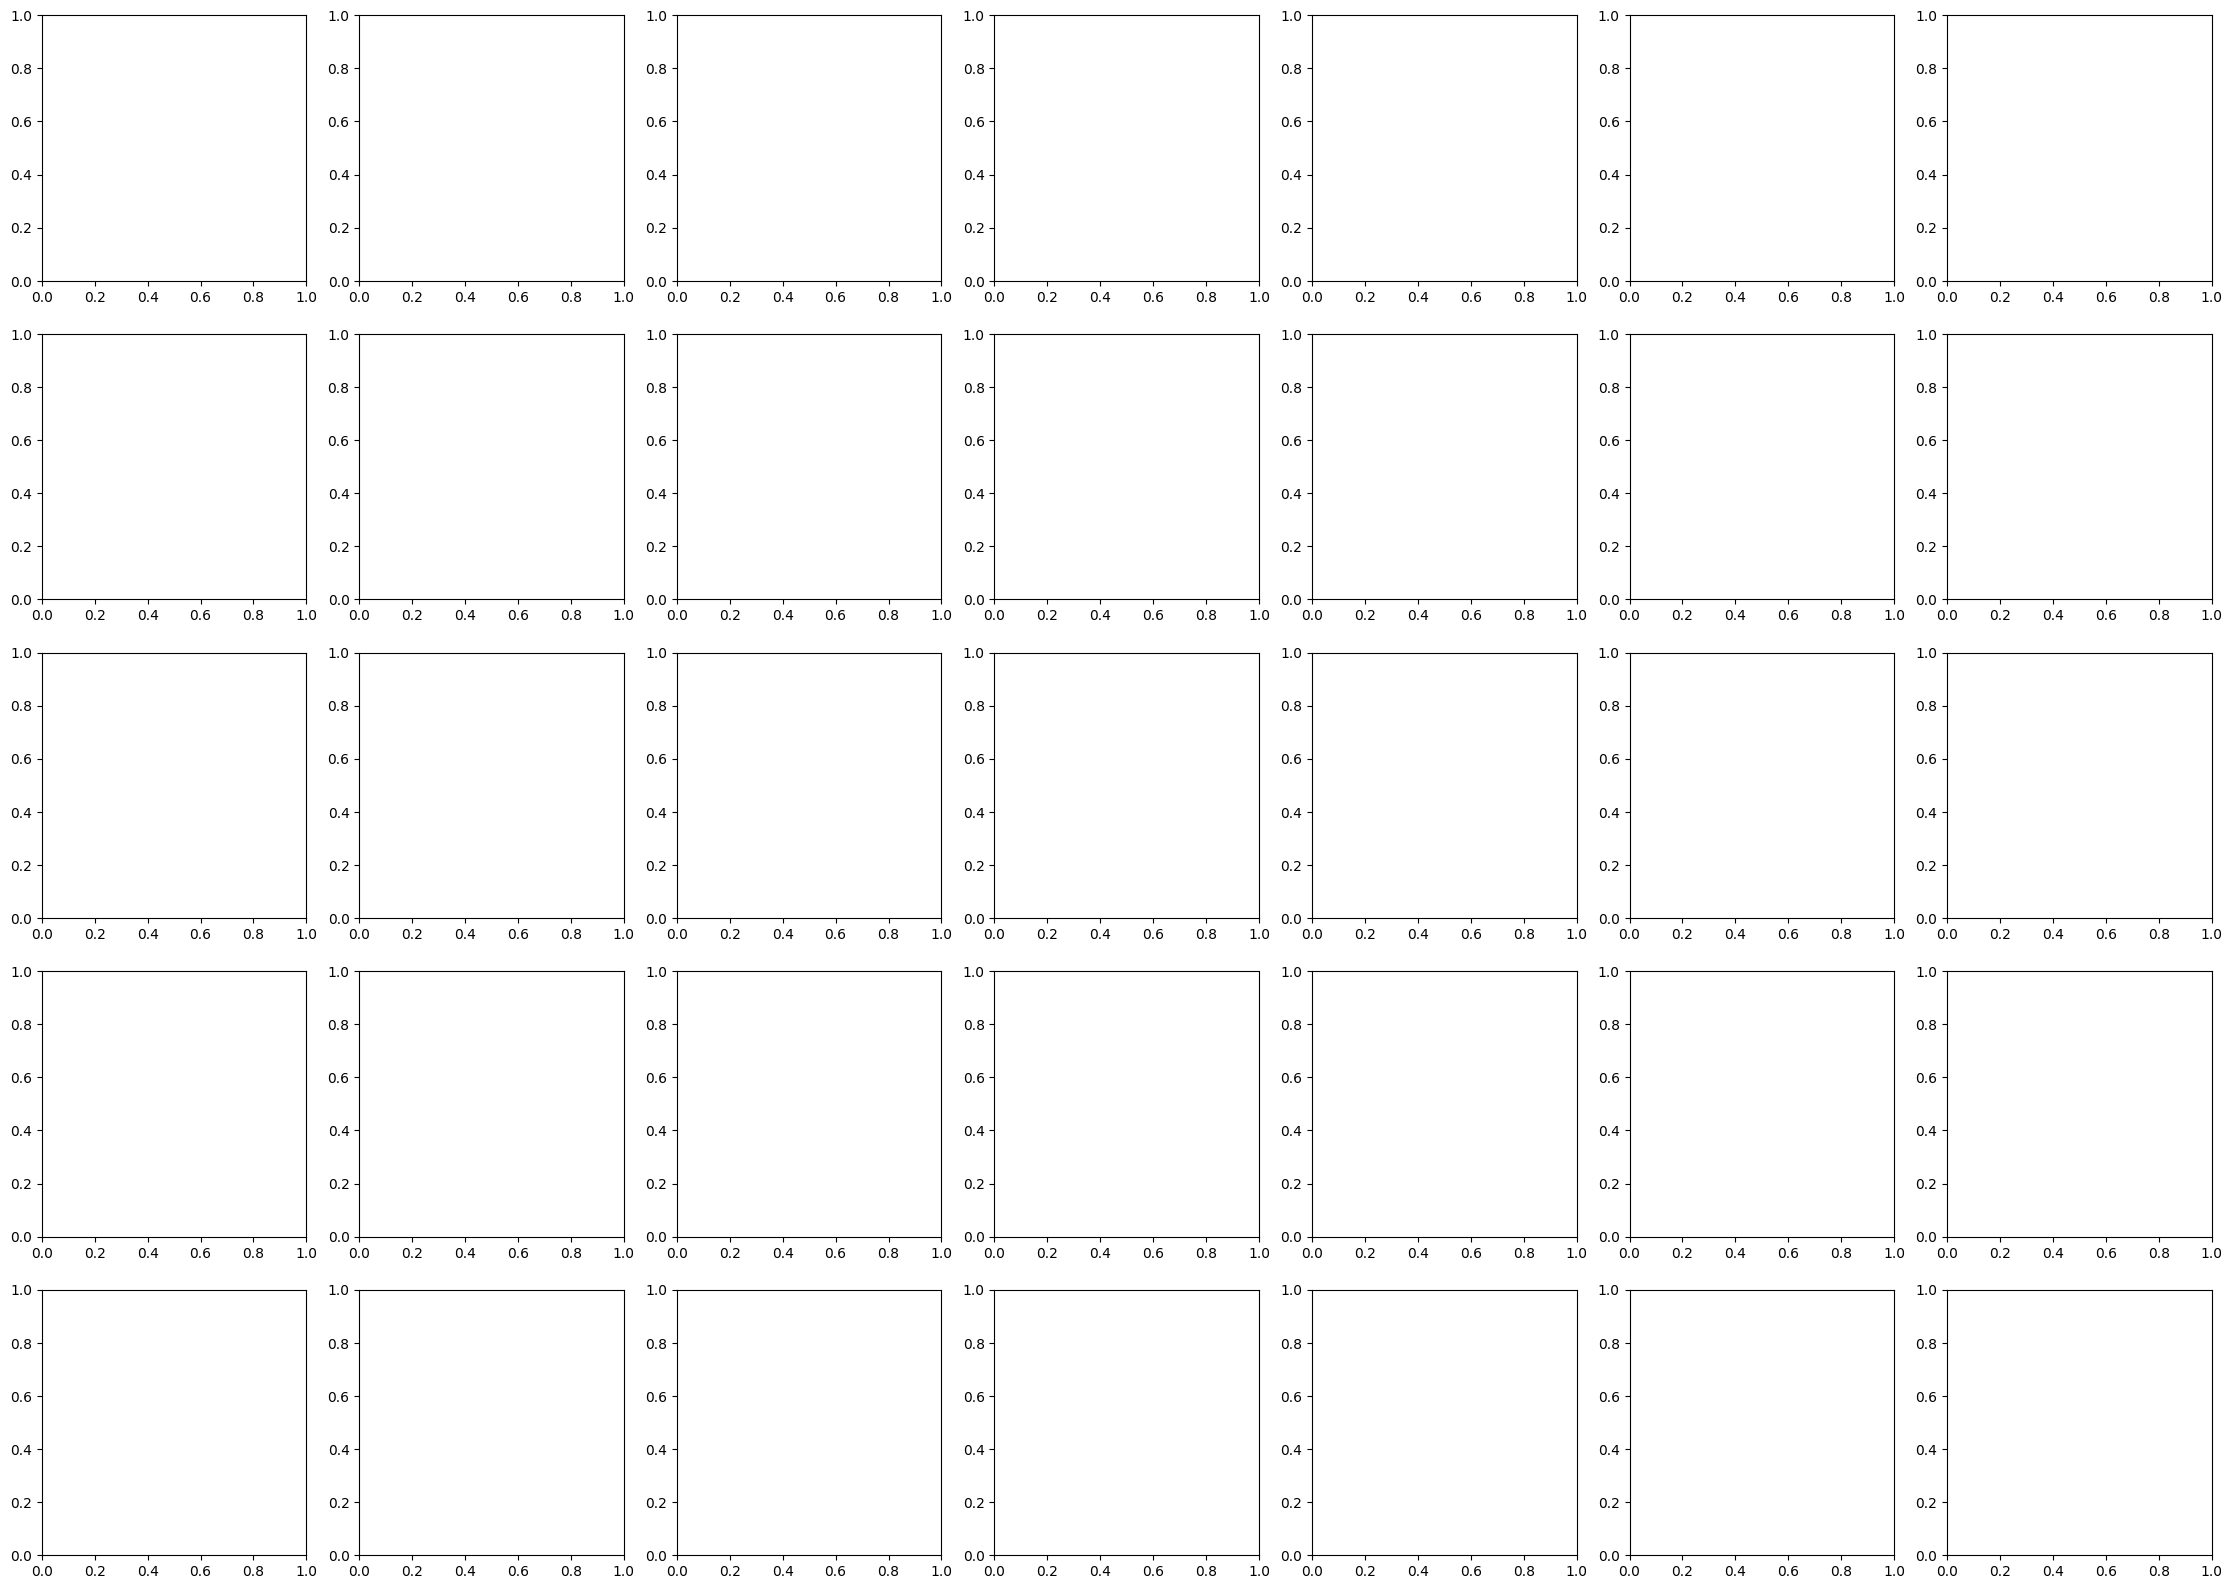

In [10]:
# ============================================================
# 9) Karşılaştırma bar grafiği + yan yana nitel grid (ürün dahil)
# ============================================================
# --- bar grafiği (anahtar metrikler) ---
show=["ocr_psnr","ocr_ssim","ocr_msssim","mask_dice","mask_bf1","canvas_psnr","canvas_ssim"]
labels=[NICE[k].replace(" ↑","").replace(" ↓","") for k in show]
ov=[old_metrics[k] for k in show]; nv=[new_metrics[k] for k in show]
x=np.arange(len(show)); w=0.38
fig,ax=plt.subplots(figsize=(15,6))
ax.bar(x-w/2, ov, w, label="Eski (v2, denetimli)", color="#94a3b8")
ax.bar(x+w/2, nv, w, label="Yeni (denetimli+GAN)", color="#2563eb")
for i,(o,n) in enumerate(zip(ov,nv)):
    ax.text(i-w/2,o,f"{o:.2f}",ha="center",va="bottom",fontsize=8)
    ax.text(i+w/2,n,f"{n:.2f}",ha="center",va="bottom",fontsize=8,fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_title("v2 (Denetimli) vs v3 (Denetimli + Denetimsiz GAN)", fontsize=14, fontweight="bold")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.savefig(OUT_DIR/"comparison_bars.png", dpi=130, bbox_inches="tight"); plt.close()
print("kaydedildi: comparison_bars.png")

# --- nitel yan yana grid ---
@torch.no_grad()
def qualitative_compare(n=5):
    n=min(n, len(test_ds)); idxs=np.linspace(0,len(test_ds)-1,n).astype(int)
    cols=["input","v2 ocr","v3 ocr","hedef ocr","v2 canvas","v3 canvas","hedef canvas"]
    fig,ax=plt.subplots(n,len(cols),figsize=(4*len(cols),4*n)); ax=np.atleast_2d(ax)
    for r,idx in enumerate(idxs):
        it=test_ds[idx]; inp=it["input"].unsqueeze(0).to(DEVICE)
        with amp_ctx():
            o1=old_model(inp); o2=new_model(inp)
        ocr1=o1["ocr"].clamp(0,1)[0].cpu(); ocr2=o2["ocr"].clamp(0,1)[0].cpu()
        m1=torch.sigmoid(o1["mask_logits"])[0,0].cpu().numpy(); m2=torch.sigmoid(o2["mask_logits"])[0,0].cpu().numpy()
        c1=make_white_canvas_np(ocr1.numpy(),m1); c2=make_white_canvas_np(ocr2.numpy(),m2)
        gtm=it["text_mask"][0].numpy(); gc_=make_white_canvas_np(it["target_ocr"].numpy(),gtm)
        imgs=[it["input"].permute(1,2,0).numpy(), ocr1.permute(1,2,0).numpy(), ocr2.permute(1,2,0).numpy(),
              it["target_ocr"].permute(1,2,0).numpy(), c1, c2, gc_]
        for j,(t,img) in enumerate(zip(cols,imgs)):
            ax[r,j].imshow(img);
            if r==0: ax[r,j].set_title(t, fontsize=11, fontweight="bold")
            ax[r,j].axis("off")
    plt.suptitle("Nitel Karşılaştırma — Eski (v2) vs Yeni (v3) — Ürün: white_canvas", fontsize=14, fontweight="bold")
    plt.tight_layout(); plt.savefig(OUT_DIR/"qualitative_compare.png", dpi=110, bbox_inches="tight"); plt.close()
    print("kaydedildi: qualitative_compare.png")

qualitative_compare(5)

In [11]:
# ============================================================
# 10) GAN-izole analiz: denetimli plato -> GAN sonrası
#     (v3 eğitim raporundan; denetimsizliğin TEK BAŞINA katkısı)
# ============================================================
GAN_EFFECT = None
if Path(NEW_REPORT_JSON).exists():
    rep = json.loads(Path(NEW_REPORT_JSON).read_text(encoding="utf-8"))
    sm = rep.get("stage_metrics", {})
    sup = sm.get("after_stage2"); gan = sm.get("FINAL") or sm.get("after_stage3_gan")
    if sup and gan:
        GAN_EFFECT = (sup, gan)
        keys=["ocr_psnr","ocr_ssim","ocr_msssim","mask_dice","canvas_psnr","canvas_ssim"]
        print("Denetimsiz GAN'ın TEK BAŞINA katkısı (aynı model, GAN öncesi -> sonrası):")
        print(f"{'Metrik':<22}{'Denetimli son':>15}{'GAN sonrası':>13}{'Δ':>10}")
        for k in keys:
            print(f"{NICE.get(k,k):<22}{sup[k]:>15.4f}{gan[k]:>13.4f}{gan[k]-sup[k]:>+10.4f}")
        # grafik
        x=np.arange(len(keys)); w=0.38
        fig,ax=plt.subplots(figsize=(13,5.5))
        ax.bar(x-w/2,[sup[k] for k in keys],w,label="Denetimli son (Stage 2)",color="#f59e0b")
        ax.bar(x+w/2,[gan[k] for k in keys],w,label="Denetimsiz GAN sonrası",color="#16a34a")
        ax.set_xticks(x); ax.set_xticklabels([NICE.get(k,k).replace(" ↑","") for k in keys], rotation=20, ha="right")
        ax.set_title("Denetimsiz GAN'ın Katkısı (denetimli plato → GAN sonrası)", fontsize=13, fontweight="bold")
        ax.legend(); ax.grid(alpha=0.3, axis="y")
        plt.tight_layout(); plt.savefig(OUT_DIR/"gan_isolated_effect.png", dpi=130, bbox_inches="tight"); plt.close()
        print("\nkaydedildi: gan_isolated_effect.png")
else:
    print("v3 rapor json bulunamadı; GAN-izole analiz atlandı.")
    print("(Bu opsiyonel. Yol:", NEW_REPORT_JSON, ")")

Denetimsiz GAN'ın TEK BAŞINA katkısı (aynı model, GAN öncesi -> sonrası):
Metrik                  Denetimli son  GAN sonrası         Δ
OCR PSNR (dB) ↑               18.6394      24.8144   +6.1750
OCR SSIM ↑                     0.1765       0.5082   +0.3317
OCR MS-SSIM ↑                  0.4339       0.7888   +0.3549
Mask Dice ↑                    0.7087       0.7159   +0.0072
Canvas PSNR (dB) ↑            30.3231      30.8369   +0.5138
Canvas SSIM ↑                  0.9765       0.9767   +0.0003

kaydedildi: gan_isolated_effect.png


In [12]:
# ============================================================
# 11) SLAYT METNİ üret (neden daha başarılı + denetimsizi nasıl yaptık)
# ============================================================
o_p, n_p = old_metrics["ocr_psnr"], new_metrics["ocr_psnr"]
o_s, n_s = old_metrics["ocr_ssim"], new_metrics["ocr_ssim"]
o_d, n_d = old_metrics["mask_dice"], new_metrics["mask_dice"]
o_cp, n_cp = old_metrics["canvas_psnr"], new_metrics["canvas_psnr"]

gan_line = ""
if GAN_EFFECT is not None:
    sup, gan = GAN_EFFECT
    gan_line = (f"- Aynı model üzerinde **sadece** denetimsiz GAN fazı, OCR PSNR'ı "
                f"{sup['ocr_psnr']:.1f} → {gan['ocr_psnr']:.1f} dB ve OCR SSIM'i "
                f"{sup['ocr_ssim']:.2f} → {gan['ocr_ssim']:.2f} yaptı — yani sıçramanın büyük kısmı "
                f"denetimsiz fazdan geldi.\n")

slide = f"""# Slayt: Denetimli + Denetimsiz Öğrenme ile Daha Başarılı Model

## Sonuç (test seti, aynı veri, aynı metrikler)
- **OCR PSNR**: {o_p:.1f} → **{n_p:.1f} dB**   (+{n_p-o_p:.1f} dB)
- **OCR SSIM**: {o_s:.3f} → **{n_s:.3f}**
- **Mask Dice/F1**: {o_d:.3f} → **{n_d:.3f}**  |  Boundary-F1: {new_metrics['mask_bf1']:.3f}
- **Ürün (white_canvas) PSNR**: {o_cp:.1f} → **{n_cp:.1f} dB**, SSIM {new_metrics['canvas_ssim']:.3f}
{gan_line}
---

## Neden denetimli + denetimsiz (GAN) daha başarılı?

**1. Denetimli kayıp "ortalama"da takılır (bulanık optimum).**
L1/Charbonnier + SSIM gibi denetimli kayıplar piksel/yapı ortalamasını minimize eder; bu da olası
çıktıların ortalamasına, yani **bulanık, düşük kontrastlı yazıya** yakınsar. Eğitimde bunu gözlemledik:
denetimli aşama OCR'da ~18-19 dB / ~0.18 SSIM'de platoya girdi ve daha fazla denetimli epoch ile
ilerlemedi (hatta hafif geriledi = aşırı yumuşatma).

**2. Discriminator, piksel kaybının veremeyeceği "dağılım-seviyesi" sinyali verir.**
Denetimsiz adversarial sinyal "şu pikseli birebir tuttur" demez; **"bu çıktı gerçek temiz-yazı
görüntülerine benziyor mu?"** diye sorar. Bu, üreticiyi piksel-ortalamasına değil, gerçek keskin
yazının **manifolduna** iter. Bu yüzden bulanıklıktan çıkıp keskin/kontrastlı yazı üretir.

**3. Feature matching, hem gerçekçiliği hem doğruluğu birlikte artırdı.**
Discriminator ara-katman özelliklerini eşleştiren feature-matching kaybı (yüksek ağırlık), öğrenilmiş
güçlü bir algısal kayıp gibi davranır. Sonuç: **PSNR ve SSIM birlikte yükseldi** — yani sadece "güzel
görünen ama yanlış" değil, hem gerçekçi hem hedefe yapısal olarak daha yakın çıktı.

**4. "Önce denetimli, sonra denetimsiz" sıralaması kritik.**
Denetimli aşama doğru yapısal temeli kurar (kaba eşleme öğrenilir); denetimsiz GAN bu temeli
gerçekçiliğe doğru **rafine eder**. GAN'ı sıfırdan başlatmak kararsız olurdu; denetimli tabandan
başlatınca adversarial sinyal odaklı bir ince ayar yapar. İkisi ayrı ayrı değil, **birlikte** en iyisini verdi.

---

## Denetimsiz eğitimi nasıl yaptık? (yöntem)

**Mimari:** Aynı NAFNet multi-head üretici (generator). Yanına bir **PatchGAN discriminator** ekledik;
girdi tahta görüntüsü + OCR çıktısını birlikte alır (koşullu / pix2pix tarzı) ve görüntüyü parça parça
"gerçek/sahte" olarak puanlar.

**Discriminator = denetimsiz "öğretmen":** Gerçek OCR-hedef görüntüleri ile üreticinin ürettiklerini
ayırmayı öğrenir. Üreticiye **piksel etiketi olmadan** gradyan verir — üretici sadece discriminator'ı
kandıracak (gerçeğe benzeyen) çıktı üretmeye çalışır. Sinyalin denetimsizliği buradadır: hedefin tek
tek piksel değerleri değil, **gerçek verinin dağılımı** kullanılır.

**Kayıplar (GAN fazı):**
- **LSGAN (least-squares) adversarial** — klasik GAN'dan daha kararlı.
- **Feature matching** — discriminator ara özelliklerini eşle (kararlılık + kalite, yüksek ağırlık).
- **Hafif denetimli çapa** — model doğruluktan kopmasın (halüsinasyonu önler) diye küçük bir denetimli terim.
- **Spectral normalization** (discriminator'da) — discriminator'ın aşırı güçlenmesini engeller (kararlılık).

**Eğitim döngüsü:** Dönüşümlü iki adım — (1) D-adımı: discriminator'ı gerçek vs üretilen üzerinde eğit;
(2) G-adımı: üreticiyi discriminator'ı kandıracak + feature matching + denetimli çapa ile eğit.
Üreticide **EMA** (exponential moving average) ile kararlı ağırlık tutuldu. bfloat16, A100.

**Özet:** Denetimli aşamada modele "doğru cevabı" öğrettik; denetimsiz aşamada ona "gerçekçi görün"
baskısı uyguladık. İkincisi, denetimlinin ulaşamadığı keskinlik ve kontrastı kazandırdı.
"""
(OUT_DIR/"SLIDE_TEXT.md").write_text(slide, encoding="utf-8")
print(slide)
print("\nKaydedildi: SLIDE_TEXT.md")

# --- her şeyi Drive'a kopyala + sun ---
for f in OUT_DIR.glob("*"):
    try: shutil.copy2(f, DRIVE_OUT/f.name)
    except Exception as e: print("kopya hata:", e)
print("\nTüm çıktılar Drive'a kopyalandı:", DRIVE_OUT)
print("Dosyalar:", [f.name for f in OUT_DIR.glob("*")])

# Slayt: Denetimli + Denetimsiz Öğrenme ile Daha Başarılı Model

## Sonuç (test seti, aynı veri, aynı metrikler)
- **OCR PSNR**: 17.9 → **24.8 dB**   (+6.9 dB)
- **OCR SSIM**: 0.154 → **0.508**
- **Mask Dice/F1**: 0.720 → **0.716**  |  Boundary-F1: 0.971
- **Ürün (white_canvas) PSNR**: 30.7 → **30.8 dB**, SSIM 0.977
- Aynı model üzerinde **sadece** denetimsiz GAN fazı, OCR PSNR'ı 18.6 → 24.8 dB ve OCR SSIM'i 0.18 → 0.51 yaptı — yani sıçramanın büyük kısmı denetimsiz fazdan geldi.

---

## Neden denetimli + denetimsiz (GAN) daha başarılı?

**1. Denetimli kayıp "ortalama"da takılır (bulanık optimum).**
L1/Charbonnier + SSIM gibi denetimli kayıplar piksel/yapı ortalamasını minimize eder; bu da olası
çıktıların ortalamasına, yani **bulanık, düşük kontrastlı yazıya** yakınsar. Eğitimde bunu gözlemledik:
denetimli aşama OCR'da ~18-19 dB / ~0.18 SSIM'de platoya girdi ve daha fazla denetimli epoch ile
ilerlemedi (hatta hafif geriledi = aşırı yumuşatma).

**2. Discriminator, piksel kaybının ver